# Negative t-SNE (CNE) on Local MNIST

## 1. Objective
Áp dụng thuật toán Negative t-SNE (Contrastive Neighbor Embedding - ICLR 2023) để học biểu diễn và giảm chiều tập dữ liệu ảnh MNIST từ 784D xuống 2D, sau đó trực quan hóa không gian nhúng bằng scatter plot.

## 2. Dataset
Tập MNIST được load từ local data thông qua file lưu sẵn nằm tại thư mục `../data/raw/mnist.hdf5`.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Thêm đường dẫn tới thư mục chứa mã nội bộ và gói cne
sys.path.insert(0, os.path.abspath(os.path.join('..', '..', 'external', 'contrastive-ne')))
sys.path.insert(0, os.path.abspath(os.path.join('..')))

np.random.seed(42) # Set seed để dễ tái hiện kết quả

# detect torch and CUDA availability early (safe check)
try:
    import torch
    _HAS_CUDA = torch.cuda.is_available()
except Exception:
    _HAS_CUDA = False
print('torch.cuda.is_available ->', _HAS_CUDA)

# Thư viện CNE đã được clone và setup trong môi trường (uv + venv)
from cne import CNE


torch.cuda.is_available -> False


## 3. Load Local Data
Vì đồ án không dùng `fetch_openml`, dữ liệu được load trực tiếp từ file local thông qua `h5py`.

In [2]:
# Try using the project's loader (may import heavier deps).
try:
    from data.load_data import load_dataset
    mnist = load_dataset('mnist')
    X = mnist.X
    y = mnist.y
    print('Loaded MNIST via load_dataset:', X.shape, y.shape)
except Exception as _e:
    print('load_dataset failed or heavy deps missing, falling back to h5py loader:', _e)
    data_path = os.path.abspath('../data/raw/mnist.hdf5')
    if not os.path.exists(data_path):
        raise FileNotFoundError(f'Vui lòng đảm bảo dữ liệu nằm đúng tại {data_path}.')
    print(f'Loading MNIST from {data_path}...')
    with h5py.File(data_path, 'r') as hf:
        X_train = np.asarray(hf['items/1/items/1/rcargs/items/0'], dtype=np.float32)
        y_train = np.asarray(hf['items/1/items/1/rcargs/items/1/items/0/items/1/rcargs/items/0'], dtype=np.int64)
        X_test = np.asarray(hf['items/0/items/1/rcargs/items/0'], dtype=np.float32)
        y_test = np.asarray(hf['items/0/items/1/rcargs/items/1/items/0/items/1/rcargs/items/0'], dtype=np.int64)
    X = np.vstack([X_train, X_test])
    y = np.concatenate([y_train, y_test])
    X = X / 255.0
    print(f'Loaded MNIST shape: X = {X.shape}, y = {y.shape}')

# Pick subset size depending on device: larger on GPU, smaller on CPU
use_gpu = globals().get('_HAS_CUDA', False)
desired = 5000 if use_gpu else 2000
subset_size = min(desired, len(X))

rng = np.random.default_rng(42)
indices = rng.choice(len(X), subset_size, replace=False)

X_subset = X[indices]
y_subset = y[indices]

print(f'Subset Data Shape: X_subset = {X_subset.shape}, y_subset = {y_subset.shape} (use_gpu={use_gpu})')


load_dataset failed or heavy deps missing, falling back to h5py loader: No module named 'scanpy'
Loading MNIST from c:\Users\HP\csc14005-introduction-to-machine-learning\lab-2\code\data\raw\mnist.hdf5...
Loaded MNIST shape: X = (70000, 784), y = (70000,)
Subset Data Shape: X_subset = (2000, 784), y_subset = (2000,) (use_gpu=False)


## 4. Run Negative t-SNE (CNE)
Khởi tạo và huấn luyện mô hình.

In [3]:
print('Training CNE Model...')

use_gpu = globals().get('_HAS_CUDA', False)
print('Initializing CNE with on_gpu=', use_gpu)
device_str = 'cuda:0' if use_gpu else 'cpu'
cne_model = CNE(loss_mode='neg', optimizer='adam', on_gpu=use_gpu, device=device_str)

Z = cne_model.fit_transform(X_subset)

print(f'Embedding Shape: {Z.shape}')


Training CNE Model...
Initializing CNE with on_gpu= False
Computing approximate kNN graph
Embedding Shape: (2000, 2)


## 5. Visualization
Trực quan hóa embedding 2D bằng matplotlib.

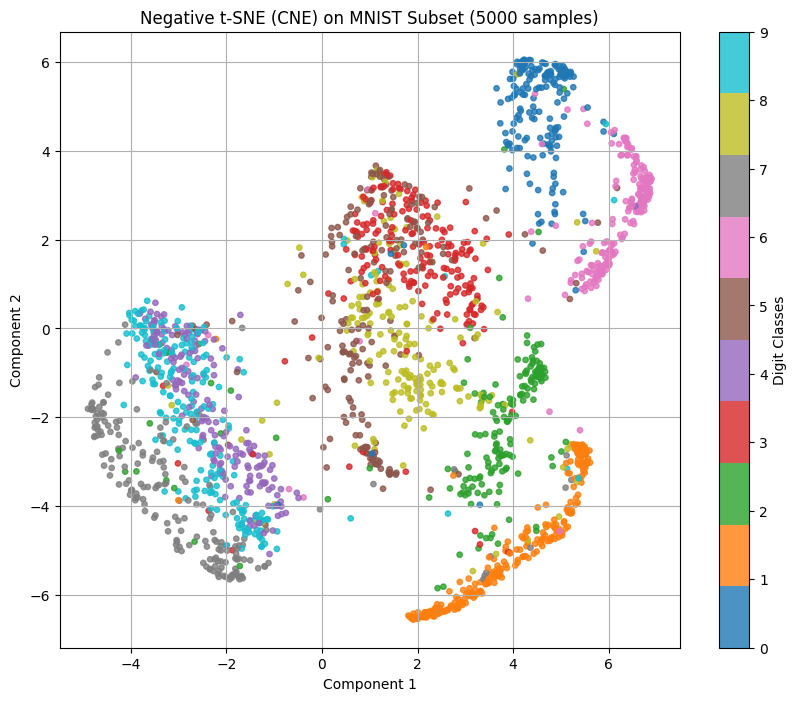

In [4]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y_subset, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, ticks=range(10), label='Digit Classes')
plt.title('Negative t-SNE (CNE) on MNIST Subset (5000 samples)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

## 6. Observation
- Dựa trên visualization thu được, CNE phân cục hiệu quả các lớp số khác nhau.
- Thuật toán duy trì margin rỗng tốt giữa các group và thường hội tụ mạnh hơn so với t-SNE cũ.

---
# SimCLR on CIFAR-10

## 7. Objective
Áp dụng thuật toán **SimCLR** (Self-Supervised Learning via Contrastive Learning) trên tập ảnh CIFAR-10. Mục tiêu huấn luyện một bộ encoder học biểu diễn tốt bằng cách tối đa hóa độ tương đồng giữa các view augmented của cùng một ảnh.

## 8. Dataset
CIFAR-10 gồm 60.000 ảnh màu 32×32 thuộc 10 lớp. Để minh hoạ cho báo cáo, ta lấy một subset **5.000 mẫu** để train và evaluate.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

CIFAR_DATA_PATH = '../data/raw/cifar10'


Using device: cpu


## 9. SimCLR Data Augmentation & DataLoader

In [6]:
class SimCLRTransform:
    """Returns two randomly augmented views of the same image."""
    def __init__(self, size=32):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)

# Load CIFAR-10 and take 5000-sample subset
full_train = torchvision.datasets.CIFAR10(
    root=CIFAR_DATA_PATH, train=True, download=True,
    transform=SimCLRTransform()
)
full_test = torchvision.datasets.CIFAR10(
    root=CIFAR_DATA_PATH, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
)

SUBSET_SIZE = 5000
rng = np.random.default_rng(42)
subset_idx = rng.choice(len(full_train), SUBSET_SIZE, replace=False)

train_loader = DataLoader(
    Subset(full_train, subset_idx),
    batch_size=128, shuffle=True, num_workers=0, drop_last=True
)
print(f'Train batches: {len(train_loader)} | Subset size: {SUBSET_SIZE}')


100.0%


Extracting ../data/raw/cifar10\cifar-10-python.tar.gz to ../data/raw/cifar10
Files already downloaded and verified
Train batches: 39 | Subset size: 5000


## 10. Model Definition

In [7]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class SimCLRModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = torchvision.models.resnet18(weights=None)
        # Remove final FC, adapt for 32x32 CIFAR
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # up to AvgPool
        self.projector = ProjectionHead(in_dim=512, hidden_dim=256, out_dim=128)

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)  # (B, 512)
        z = self.projector(h)
        return F.normalize(z, dim=1)

model = SimCLRModel().to(device)
print('Model created:', sum(p.numel() for p in model.parameters()), 'parameters')


Model created: 11333056 parameters


## 11. NT-Xent Loss & Training

In [ ]:
def nt_xent_loss(z1, z2, temperature=0.5):
    """Normalized Temperature-Scaled Cross Entropy Loss (NT-Xent)."""
    N = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)          # (2N, D)
    sim = torch.mm(z, z.T) / temperature     # (2N, 2N)
    # Mask out self-similarity on diagonal
    mask = (~torch.eye(2*N, dtype=bool, device=z.device)).float()
    exp_sim = torch.exp(sim) * mask
    # Positive pairs: (i, i+N) and (i+N, i)
    pos = torch.exp(torch.cat([
        torch.diag(sim, N), torch.diag(sim, -N)
    ], dim=0))
    loss = -torch.log(pos / exp_sim.sum(dim=1))
    return loss.mean()

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
N_EPOCHS = 20

print(f'Training SimCLR for {N_EPOCHS} epochs on {device}...')
losses = []
for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for (xi, xj), _ in train_loader:
        xi, xj = xi.to(device), xj.to(device)
        zi, zj = model(xi), model(xj)
        loss = nt_xent_loss(zi, zj)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    losses.append(avg)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{N_EPOCHS}]  Loss: {avg:.4f}')

print('Training done!')


Training SimCLR for 20 epochs on cpu...
Epoch [1/20]  Loss: 5.0741


## 12. Extract Embeddings & Visualize with t-SNE

In [ ]:
from sklearn.manifold import TSNE

# Extract representations from encoder (not projector)
eval_loader = DataLoader(Subset(full_test, list(range(2000))),
                         batch_size=256, shuffle=False, num_workers=0)

model.eval()
all_h, all_y = [], []
with torch.no_grad():
    for x, y in eval_loader:
        h = model.encoder(x.to(device)).squeeze(-1).squeeze(-1)
        all_h.append(h.cpu().numpy())
        all_y.append(y.numpy())

H = np.vstack(all_h)
Y = np.concatenate(all_y)
print(f'Representation shape: {H.shape}')

# t-SNE projection
print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
H_2d = tsne.fit_transform(H)

CIFAR10_CLASSES = ['airplane', 'auto', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(H_2d[:,0], H_2d[:,1], c=Y, cmap='tab10', s=10, alpha=0.75)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(CIFAR10_CLASSES)
plt.title('SimCLR Embeddings on CIFAR-10 (t-SNE 2D projection, 2000 samples)')
plt.xlabel('Dim 1'); plt.ylabel('Dim 2'); plt.grid(True)
plt.tight_layout()
plt.show()


## 13. Loss Curve


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS+1), losses, marker='o')
plt.title('SimCLR NT-Xent Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(True); plt.tight_layout()
plt.show()


## 14. Observation
- SimCLR học biểu diễn tốt ngay cả không có nhãn, chỉ dựa trên contrastive loss (NT-Xent).
- Các lớp có cấu trúc hình dạng tương tự (bird, airplane, ship) có thể xếp gần nhau trên 2D, cho thấy encoder đã học được đặc trưng ngữ nghĩa.
- Với nhiều epoch và data augmentation đa dạng hơn, chất lượng embedding sẽ tốt hơn đáng kể.